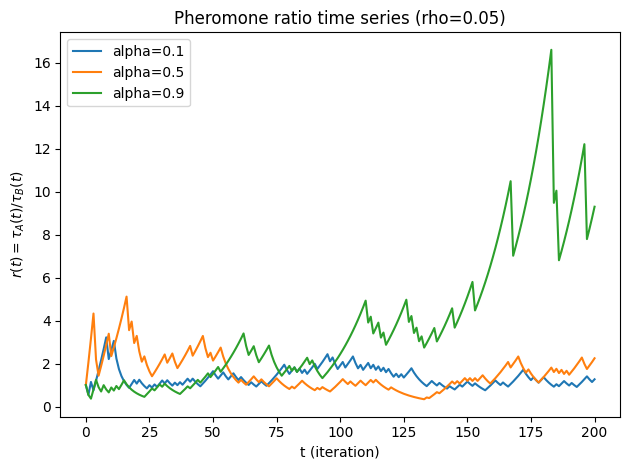

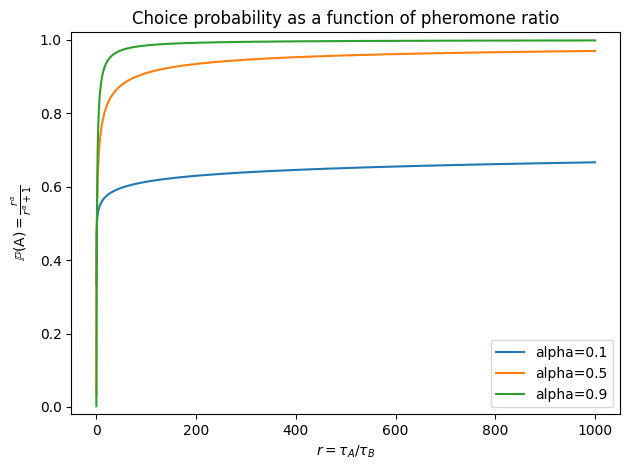

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_2choice_ratio(
    alpha: float,
    T: int = 200,
    rho: float = 0.05,
    tau0: float = 1.0,
    Q: float = 1.0,
    reward_A: float = 1.0,
    reward_B: float = 0.8,
    seed: int = 0,
):
    """
    2択ACO toy model:
      - Decision: P(A)=tauA^alpha/(tauA^alpha+tauB^alpha)
      - Evaporation: tau <- (1-rho)*tau
      - Deposit: chosen side gets +Q*reward (reward_A, reward_B are constants here)
    Returns:
      r[t] = tauA(t)/tauB(t), length T+1
    """
    rng = np.random.default_rng(seed)

    tauA = float(tau0)
    tauB = float(tau0)

    r = np.empty(T + 1, dtype=float)
    r[0] = tauA / tauB

    for t in range(T):
        pA = (tauA ** alpha) / ((tauA ** alpha) + (tauB ** alpha))
        choose_A = (rng.random() < pA)

        # evaporation
        tauA *= (1.0 - rho)
        tauB *= (1.0 - rho)

        # deposit
        if choose_A:
            tauA += Q * reward_A
        else:
            tauB += Q * reward_B

        r[t + 1] = tauA / tauB

    return r


def plot_ratio_timeseries_overlaid(
    alphas=(0.1, 0.5, 0.9),
    T: int = 200,
    rho: float = 0.05,
    tau0: float = 1.0,
    Q: float = 1.0,
    reward_A: float = 1.0,
    reward_B: float = 0.8,
    base_seed: int = 1234,
    outfile: str = "fig_ratio_timeseries_overlaid.png",
):
    t = np.arange(T + 1)

    plt.figure()
    for i, a in enumerate(alphas):
        r = simulate_2choice_ratio(
            alpha=a, T=T, rho=rho, tau0=tau0, Q=Q,
            reward_A=reward_A, reward_B=reward_B,
            seed=base_seed + i
        )
        plt.plot(t, r, label=f"alpha={a}")

    plt.xlabel("t (iteration)")
    plt.ylabel(r"$r(t)=\tau_A(t)/\tau_B(t)$")
    plt.title(f"Pheromone ratio time series (rho={rho})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(outfile, dpi=300)


def plot_choice_probability_vs_ratio(
    alphas=(0.1, 0.5, 0.9),
    r_min: float = 1e-3,
    r_max: float = 1e3,
    n: int = 2000,
    outfile: str = "fig_choice_probability_vs_ratio.png",
):
    r = np.logspace(np.log10(r_min), np.log10(r_max), n)

    plt.figure()
    for a in alphas:
        p = (r ** a) / ((r ** a) + 1.0)
        plt.plot(r, p, label=f"alpha={a}")

    plt.xlabel(r"$r=\tau_A/\tau_B$")
    plt.ylabel(r"$\mathbb{P}(\mathrm{A})=\frac{r^\alpha}{r^\alpha+1}$")
    plt.title("Choice probability as a function of pheromone ratio")
    plt.ylim(-0.02, 1.02)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outfile, dpi=300)


if __name__ == "__main__":
    alphas = (0.1, 0.5, 0.9)

    # 図2.3：フェロモン比 r(t) の時系列（3本を重ね描き）
    plot_ratio_timeseries_overlaid(
        alphas=alphas,
        T=200,
        rho=0.05,
        tau0=1.0,
        Q=1.0,
        reward_A=1.0,
        reward_B=0.8,
        outfile="fig_ratio_timeseries_overlaid.png",
    )

    # 図2.2：横軸 r、縦軸 P(A)（3本を重ね描き）
    plot_choice_probability_vs_ratio(
        alphas=alphas,
        r_min=1e-3,
        r_max=1e3,
        outfile="fig_choice_probability_vs_ratio.png",
    )


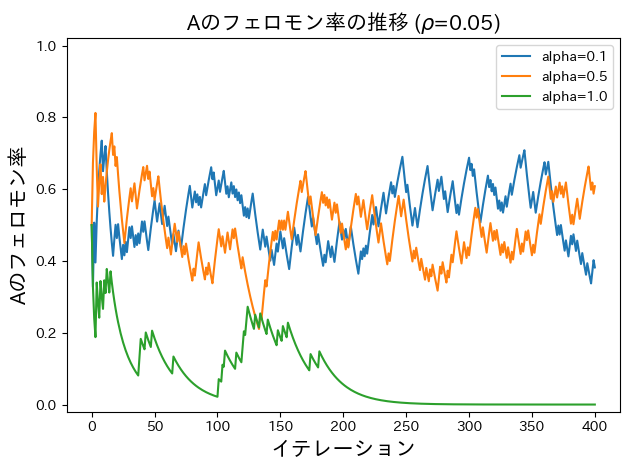

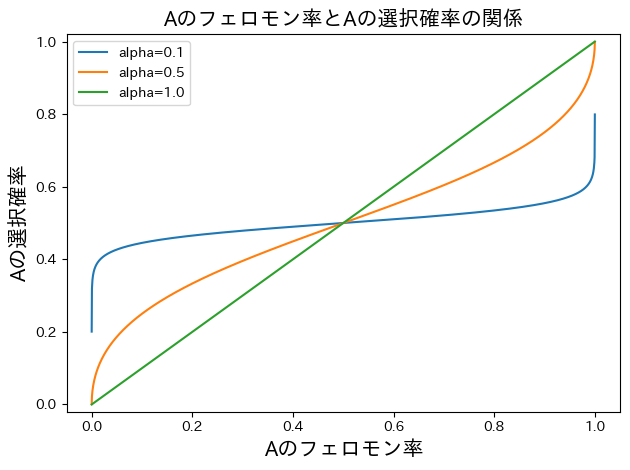

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_fontja

def simulate_2choice_pheromone_rate(
    alpha: float,
    T: int = 200,
    rho: float = 0.01,
    tau0: float = 1.0,
    Q: float = 1.0,
    reward_A: float = 1.0,
    reward_B: float = 1.0,
    seed: int = 0,
):
    """
    2択ACO toy model:
      - Decision: P(A)=tauA^alpha/(tauA^alpha+tauB^alpha)
      - Evaporation: tau <- (1-rho)*tau
      - Deposit: chosen side gets +Q*reward (reward_A, reward_B are constants)
    Returns:
      x[t] = tauA(t)/(tauA(t)+tauB(t)), length T+1
    """
    rng = np.random.default_rng(seed)
    tauA = float(tau0)
    tauB = float(tau0)

    x = np.empty(T + 1, dtype=float)
    x[0] = tauA / (tauA + tauB)

    for t in range(T):
        pA = (tauA ** alpha) / ((tauA ** alpha) + (tauB ** alpha))
        choose_A = (rng.random() < pA)

        # evaporation
        tauA *= (1.0 - rho)
        tauB *= (1.0 - rho)

        # deposit
        if choose_A:
            tauA += Q * reward_A
        else:
            tauB += Q * reward_B

        x[t + 1] = tauA / (tauA + tauB)

    return x


def plot_pheromone_rate_timeseries_overlaid(
    alphas=(0.1, 0.5, 0.9),
    T: int = 200,
    rho: float = 0.01,
    tau0: float = 1.0,
    Q: float = 1.0,
    reward_A: float = 1.0,
    reward_B: float = 1.0,
    base_seed: int = 1234,
    outfile: str = "fig_pheromone_rate_timeseries_overlaid.png",
):
    t = np.arange(T + 1)

    plt.figure()
    for i, a in enumerate(alphas):
        x = simulate_2choice_pheromone_rate(
            alpha=a, T=T, rho=rho, tau0=tau0, Q=Q,
            reward_A=reward_A, reward_B=reward_B,
            seed=base_seed + i
        )
        plt.plot(t, x, label=f"alpha={a}")

    plt.xlabel("イテレーション", fontsize=15)
    plt.ylabel("Aのフェロモン率", fontsize=15)
    plt.title(rf"Aのフェロモン率の推移 ($\rho$={rho})", fontsize=15)
    plt.ylim(-0.02, 1.02)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outfile, dpi=300)


def plot_choice_probability_vs_pheromone_rate(
    alphas=(0.1, 0.5, 0.9),
    n: int = 2000,
    eps: float = 1e-6,
    outfile: str = "fig_choice_probability_vs_pheromone_rate.png",
):
    x = np.linspace(eps, 1.0 - eps, n)

    plt.figure()
    for a in alphas:
        p = (x ** a) / ((x ** a) + ((1.0 - x) ** a))
        plt.plot(x, p, label=f"alpha={a}")

    plt.xlabel("Aのフェロモン率", fontsize=15)
    plt.ylabel("Aの選択確率", fontsize=15)
    plt.title("Aのフェロモン率とAの選択確率の関係", fontsize=15)
    plt.ylim(-0.02, 1.02)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outfile, dpi=300)


if __name__ == "__main__":
    alphas = (0.1, 0.5, 1.0)

    # 図2.3：フェロモン率 x(t) の時系列（3本を重ね描き）
    plot_pheromone_rate_timeseries_overlaid(
        alphas=alphas,
        T=400,
        rho=0.05,
        tau0=1.0,
        Q=1.0,
        reward_A=1.0,
        reward_B=1.0,
        outfile="fig_pheromone_rate_timeseries_overlaid.png",
    )

    # 図2.2：横軸 x、縦軸 P(A)（3本を重ね描き）
    plot_choice_probability_vs_pheromone_rate(
        alphas=alphas,
        outfile="fig_choice_probability_vs_pheromone_rate.png",
    )
